# 2.0 KPI Analysis Overview

- This notebook focuses on the first analytical layer built from the cleaned `orders_clean` fact table.
- The objective is to quantify core business performance through foundational restaurant KPIs.
- SQL will be used as the primary engine for metric development, aggregation, and business querying.
- The initial KPI layer will focus on:
  - total revenue
  - total orders
  - average order value
  - guest volume
  - discount usage
- These metrics establish the baseline for deeper behavioral, operational, and revenue optimization analysis in later sections.
- All KPI outputs should be interpreted through a business lens, with emphasis on revenue performance and operational decision-making.

In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# Reconnect to DuckDB
con = duckdb.connect(database=':memory:')

# Reload cleaned fact table from Workbook 1
con.execute("""
CREATE OR REPLACE TABLE orders_clean AS
SELECT * FROM read_csv_auto('data/cleaned/orders_clean.csv');
""")

# Quick validation
con.execute("SELECT COUNT(*) AS row_count FROM orders_clean").fetchdf()

,row_count
0,22156


## 2.1 Core Business KPIs

- Establish baseline performance metrics from the `orders_clean` fact table.
- Calculate total revenue to understand overall business scale.
- Count total number of orders to measure transaction volume.
- Compute Average Order Value (AOV) as a key efficiency metric.
- Measure total guest count to approximate customer volume.
- Quantify total discount dollars to understand promotional activity.
- These KPIs form the foundation for deeper behavioral and operational analysis.

In [3]:
con.execute("""
SELECT
    COUNT(*) AS total_orders,
    SUM(order_total) AS total_revenue,
    AVG(order_total) AS avg_order_value,
    SUM(guest_count) AS total_guests,
    AVG(guest_count) AS avg_guests_per_order,
    SUM(discount_amount) AS total_discount_amount
FROM orders_clean
""").fetchdf()

,total_orders,total_revenue,avg_order_value,total_guests,avg_guests_per_order,total_discount_amount
0,22156,577291.66,26.055771,27398.0,1.236595,577.18


## 2.2 Revenue and Order Volume by Quarter

- Break performance down by year and quarter to understand business scale over time.
- Measure revenue and order count at the quarter level.
- Compare AOV across quarters to identify changes in transaction efficiency.
- Use this view to identify directional growth, contraction, or seasonal movement.
- This section creates the first time-based KPI layer from the cleaned fact table.

In [4]:
con.execute("""
SELECT
    year,
    quarter,
    COUNT(*) AS total_orders,
    SUM(order_total) AS total_revenue,
    AVG(order_total) AS avg_order_value,
    SUM(guest_count) AS total_guests,
    SUM(discount_amount) AS total_discount_amount
FROM orders_clean
GROUP BY year, quarter
ORDER BY year, quarter
""").fetchdf()

,year,quarter,total_orders,total_revenue,avg_order_value,total_guests,total_discount_amount
0,2024,Q3,1761,43555.11,24.733169,2407.0,54.40
1,2024,Q4,5510,141255.22,25.636156,8415.0,114.59
2,2025,Q1,5654,147066.99,26.011141,6573.0,165.54
3,2025,Q2,6234,164726.83,26.423938,6903.0,175.19
4,2025,Q3,2997,80687.51,26.922759,3100.0,67.46


## 2.3 Daily Revenue Performance

- Aggregate the fact table to the daily level to observe day-to-day business performance.
- Measure daily revenue, daily order volume, guest volume, and AOV.
- Create a reusable `daily_kpis` table that will support later trend, seasonality, and forecasting work.
- This section establishes the daily grain needed for future operational analysis.

In [5]:
con.execute("""
CREATE OR REPLACE TABLE daily_kpis AS
SELECT
    CAST(order_datetime AS DATE) AS order_date,
    COUNT(*) AS total_orders,
    SUM(order_total) AS total_revenue,
    AVG(order_total) AS avg_order_value,
    SUM(guest_count) AS total_guests,
    SUM(discount_amount) AS total_discount_amount
FROM orders_clean
GROUP BY CAST(order_datetime AS DATE)
ORDER BY order_date
""")

con.execute("""
SELECT *
FROM daily_kpis
LIMIT 10
""").fetchdf()

,order_date,total_orders,total_revenue,avg_order_value,total_guests,total_discount_amount
0,2024-09-04,93,1946.80,20.933333,125.0,0.00
1,2024-09-05,82,1841.13,22.452805,106.0,0.00
2,2024-09-06,94,2079.40,22.121277,119.0,0.00
3,2024-09-07,58,1534.51,26.457069,70.0,0.00
4,2024-09-08,76,2328.25,30.634868,127.0,0.00
5,2024-09-09,68,1487.15,21.869853,105.0,10.00
6,2024-09-11,69,1497.46,21.702319,82.0,0.99
7,2024-09-12,71,1785.96,25.154366,87.0,3.52
8,2024-09-13,111,2801.08,25.234955,157.0,0.00
9,2024-09-14,76,2113.91,27.814605,126.0,0.00


## 2.4 Daily Revenue Trend Visualization

- Visualize daily revenue to identify trend direction, volatility, and visible peaks or slow periods.
- This chart serves as an early validation that the daily KPI pipeline is working correctly.
- Visual review also helps surface possible seasonality, unusual periods, or revenue instability.

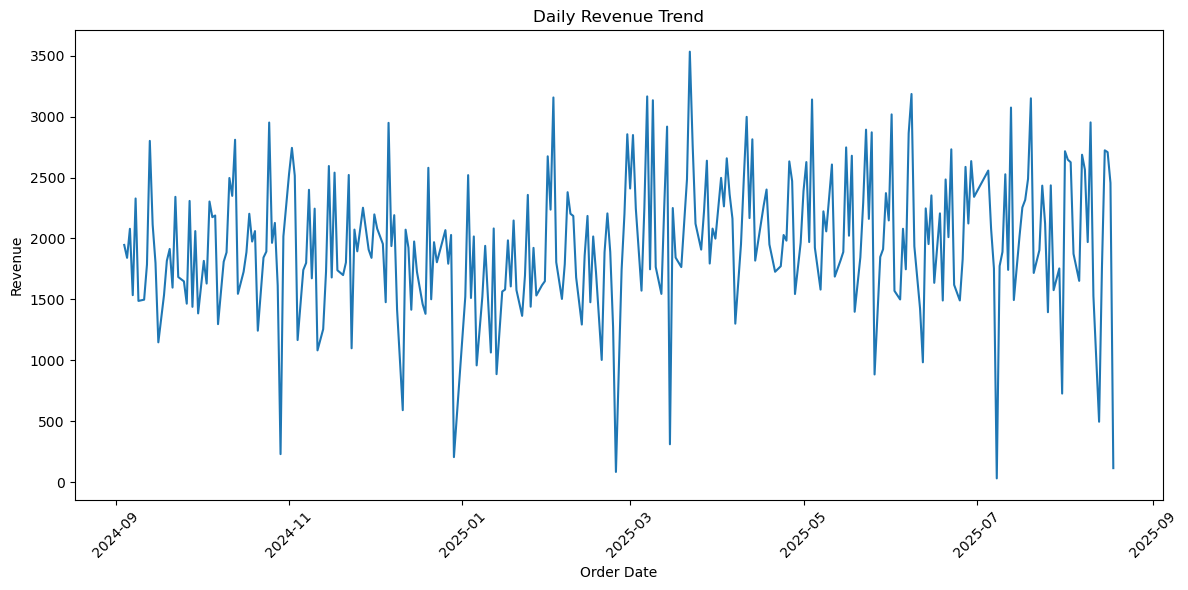

In [6]:
daily_kpis_df = con.execute("""
SELECT *
FROM daily_kpis
ORDER BY order_date
""").fetchdf()

plt.figure(figsize=(12, 6))
plt.plot(daily_kpis_df['order_date'], daily_kpis_df['total_revenue'])
plt.title('Daily Revenue Trend')
plt.xlabel('Order Date')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2.5 Daily Order Volume Trend Visualization

- Visualize daily order count to distinguish volume movement from revenue movement.
- This helps determine whether revenue changes are driven by order volume, ticket size, or both.
- Comparing order trend and revenue trend will be important in later business interpretation.

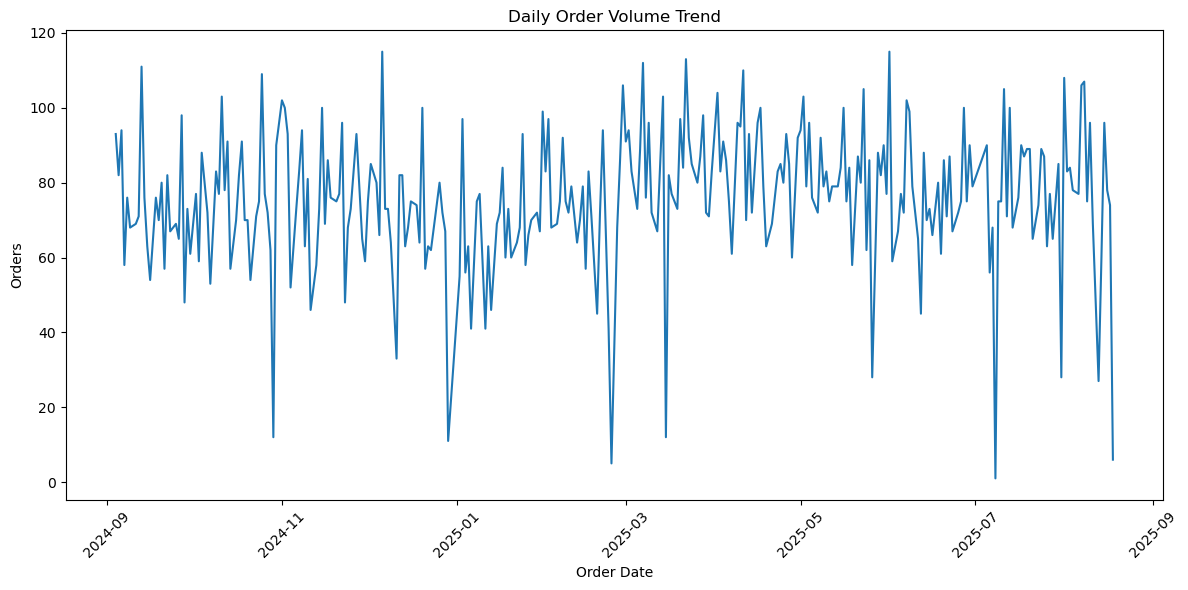

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(daily_kpis_df['order_date'], daily_kpis_df['total_orders'])
plt.title('Daily Order Volume Trend')
plt.xlabel('Order Date')
plt.ylabel('Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2.6 Initial KPI Takeaways

- The KPI layer now includes business-wide, quarterly, and daily performance views.
- `orders_clean` has been successfully reloaded into an independent analysis notebook.
- A reusable `daily_kpis` table has been created for downstream trend and operational analysis.
- The business can now be evaluated at multiple levels:
  - total performance
  - quarter-level performance
  - day-level performance
- The next stage will move from broad KPI measurement into more detailed time-based behavioral analysis.

## 2.7 Day-of-Week Performance

- Analyze performance by day of week to identify behavioral patterns in customer activity.
- Measure revenue, order volume, and AOV across each day.
- Determine which days drive the most business and which are underperforming.
- Compare revenue share vs order share to identify efficiency differences across days.
- This analysis helps inform staffing, promotions, and operational decisions.

In [8]:
con.execute("""
SELECT
    EXTRACT(DOW FROM order_datetime) AS day_of_week,
    COUNT(*) AS total_orders,
    SUM(order_total) AS total_revenue,
    AVG(order_total) AS avg_order_value,
    SUM(guest_count) AS total_guests
FROM orders_clean
GROUP BY EXTRACT(DOW FROM order_datetime)
ORDER BY day_of_week
""").fetchdf()

,day_of_week,total_orders,total_revenue,avg_order_value,total_guests
0,0,3844,116956.01,30.425601,4617.0
1,1,3121,75958.19,24.337773,4652.0
2,2,13,259.18,19.936923,19.0
3,3,3498,78805.66,22.528776,4322.0
4,4,3607,89409.21,24.787693,3962.0
5,5,4514,117406.77,26.009475,5187.0
6,6,3559,98496.64,27.675369,4639.0


## 2.8 Day-of-Week Labeling and Ordering

- Convert numeric day-of-week into readable labels for interpretation.
- Reorder results to follow a logical business sequence (Monday → Sunday).
- This improves readability and prepares the dataset for visualization.

In [9]:
import pandas as pd

dow_df = con.execute("""
SELECT
    EXTRACT(DOW FROM order_datetime) AS day_of_week,
    COUNT(*) AS total_orders,
    SUM(order_total) AS total_revenue,
    AVG(order_total) AS avg_order_value
FROM orders_clean
GROUP BY EXTRACT(DOW FROM order_datetime)
""").fetchdf()

# Map numeric day to name (DuckDB: 0=Sunday)
dow_map = {
    0: 'Sunday',
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday'
}

dow_df['day_name'] = dow_df['day_of_week'].map(dow_map)

# Reorder Monday → Sunday
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_df['day_name'] = pd.Categorical(dow_df['day_name'], categories=order, ordered=True)
dow_df = dow_df.sort_values('day_name')

dow_df

,day_of_week,total_orders,total_revenue,avg_order_value,day_name
1,1,3121,75958.19,24.337773,Monday
2,2,13,259.18,19.936923,Tuesday
3,3,3498,78805.66,22.528776,Wednesday
4,4,3607,89409.21,24.787693,Thursday
5,5,4514,117406.77,26.009475,Friday
6,6,3559,98496.64,27.675369,Saturday
0,0,3844,116956.01,30.425601,Sunday


## 2.9 Day-of-Week Revenue Visualization

- Visualize revenue by day of week to identify peak and low-performing days.
- Compare daily performance patterns to understand customer behavior.
- This helps identify opportunities for promotions or staffing adjustments.

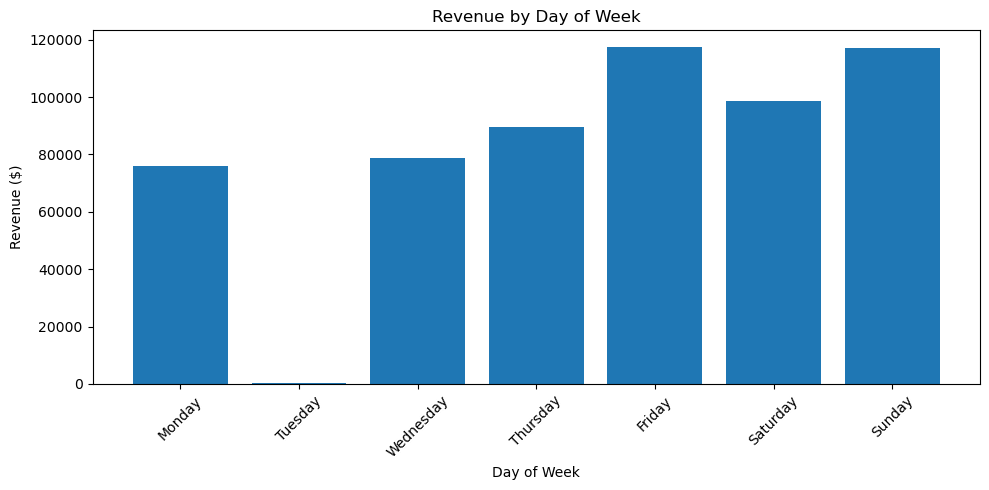

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(dow_df['day_name'], dow_df['total_revenue'])
plt.title('Revenue by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2.10 Day-of-Week Order Volume Visualization

- Visualize order volume by day to distinguish between traffic-driven and ticket-size-driven performance.
- Compare this chart with revenue to identify differences in AOV by day.c

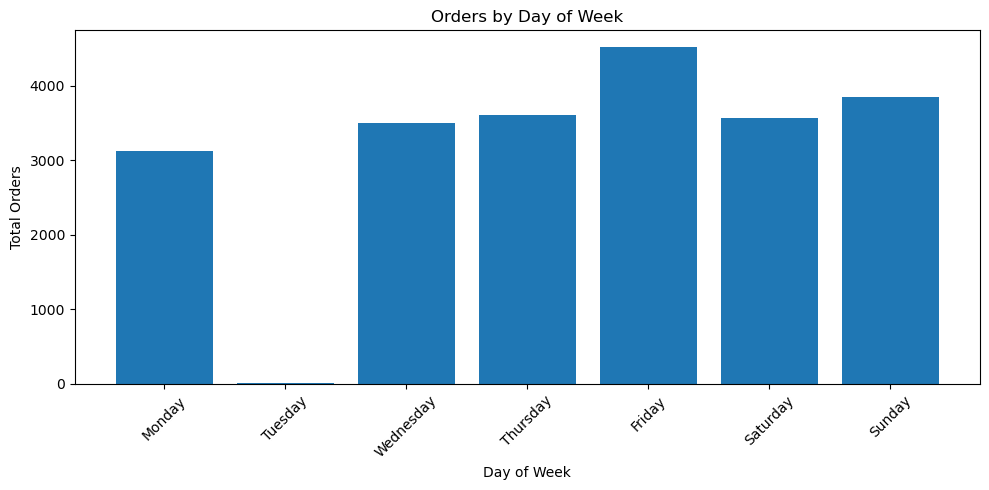

In [11]:
plt.figure(figsize=(10, 5))
plt.bar(dow_df['day_name'], dow_df['total_orders'])
plt.title('Orders by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2.11 Hour-of-Day Performance

- Analyze performance at the hourly level to understand intra-day demand patterns.
- Measure revenue, order volume, and AOV across each hour of the day.
- Identify peak hours, slow periods, and potential operational bottlenecks.
- This analysis is critical for staffing decisions, throughput planning, and revenue optimization.

In [12]:
con.execute("""
SELECT
    EXTRACT(HOUR FROM order_datetime) AS order_hour,
    COUNT(*) AS total_orders,
    SUM(order_total) AS total_revenue,
    AVG(order_total) AS avg_order_value,
    SUM(guest_count) AS total_guests
FROM orders_clean
GROUP BY EXTRACT(HOUR FROM order_datetime)
ORDER BY order_hour
""").fetchdf()

,order_hour,total_orders,total_revenue,avg_order_value,total_guests
0,9,1,5.25,5.250000,1.0
1,10,64,1024.07,16.001094,66.0
2,11,3841,92533.05,24.090875,4439.0
3,12,3259,86567.47,26.562587,3948.0
4,13,1841,42734.53,23.212672,2209.0
5,14,1381,32313.08,23.398320,1587.0
6,15,1617,40481.66,25.035040,1736.0
7,16,2517,66872.10,26.568176,3016.0
8,17,3224,90153.19,27.963148,4032.0
9,18,2838,81880.89,28.851617,4476.0


## 2.12 Hourly Revenue Visualization

- Visualize revenue distribution across hours of the day.
- Identify peak revenue windows and underutilized time periods.
- This supports operational decisions such as staffing and promotions.

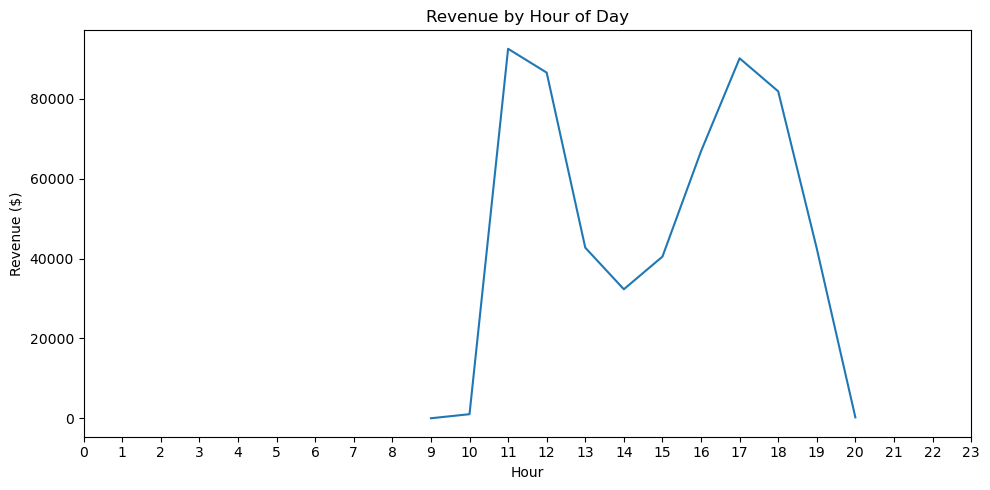

In [13]:
hour_df = con.execute("""
SELECT
    EXTRACT(HOUR FROM order_datetime) AS order_hour,
    SUM(order_total) AS total_revenue
FROM orders_clean
GROUP BY EXTRACT(HOUR FROM order_datetime)
ORDER BY order_hour
""").fetchdf()

plt.figure(figsize=(10, 5))
plt.plot(hour_df['order_hour'], hour_df['total_revenue'])
plt.title('Revenue by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Revenue ($)')
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

## 2.13 Peak Window Analysis (Day + Hour)

- Combine day-of-week and hour-of-day to identify true peak operating windows.
- Measure revenue and order volume at the (day, hour) level.
- Identify the highest-performing time blocks across the week.
- Detect underutilized periods that may represent revenue opportunities.
- This analysis is critical for staffing optimization, promotion timing, and throughput planning.

In [14]:
peak_df = con.execute("""
SELECT
    EXTRACT(DOW FROM order_datetime) AS day_of_week,
    EXTRACT(HOUR FROM order_datetime) AS order_hour,
    COUNT(*) AS total_orders,
    SUM(order_total) AS total_revenue
FROM orders_clean
GROUP BY EXTRACT(DOW FROM order_datetime), EXTRACT(HOUR FROM order_datetime)
""").fetchdf()

peak_df.head()

,day_of_week,order_hour,total_orders,total_revenue
0,0,10,7,107.71
1,0,11,588,17905.19
2,0,12,896,32876.83
3,0,13,407,11746.51
4,0,14,281,7332.12


In [15]:
# Map day names
dow_map = {
    0: 'Sunday',
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday'
}

peak_df['day_name'] = peak_df['day_of_week'].map(dow_map)

# Sort properly
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
peak_df['day_name'] = pd.Categorical(peak_df['day_name'], categories=order, ordered=True)
peak_df = peak_df.sort_values(['day_name', 'order_hour'])

peak_df.head()

,day_of_week,order_hour,total_orders,total_revenue,day_name
10,1,9,1,5.25,Monday
11,1,10,8,103.42,Monday
12,1,11,647,15012.99,Monday
13,1,12,474,10790.18,Monday
14,1,13,243,4991.09,Monday


## 2.14 Peak Window Visualization

- Visualize revenue intensity across day and hour combinations.
- Identify the highest-demand time blocks across the week.
- Highlight operational pressure points and underutilized periods.

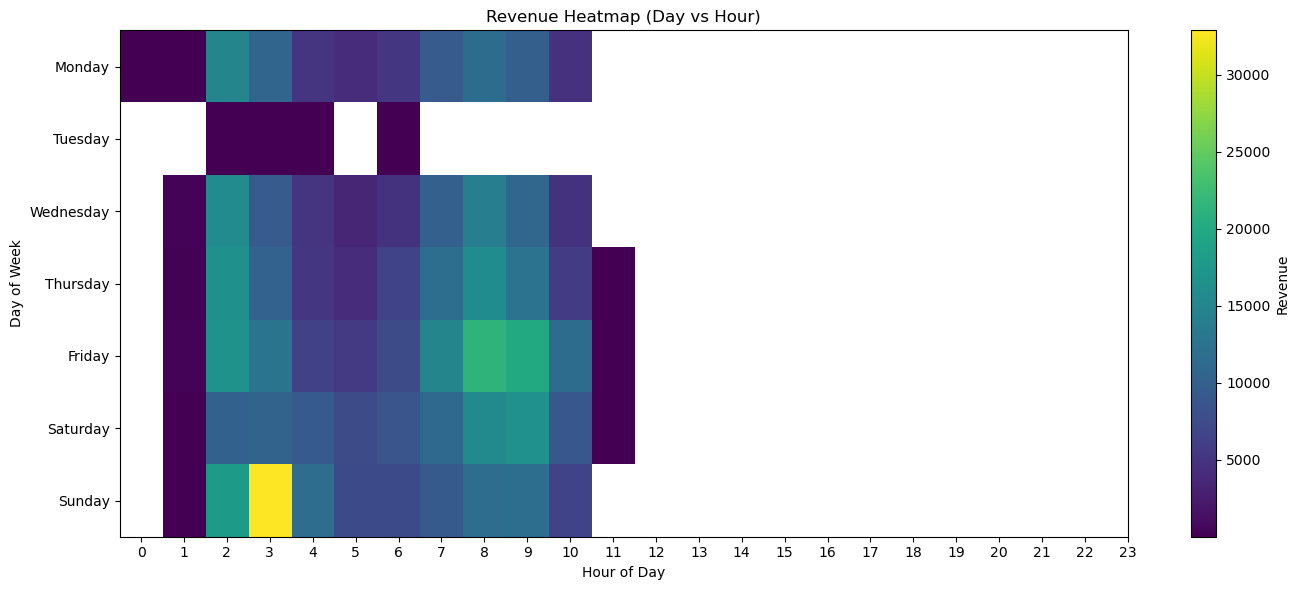

In [16]:
import matplotlib.pyplot as plt

# Pivot for heatmap-style table
pivot_df = peak_df.pivot(index='day_name', columns='order_hour', values='total_revenue')

plt.figure(figsize=(14, 6))
plt.imshow(pivot_df, aspect='auto')
plt.colorbar(label='Revenue')

plt.xticks(range(0,24), range(0,24))
plt.yticks(range(len(pivot_df.index)), pivot_df.index)

plt.title('Revenue Heatmap (Day vs Hour)')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')

plt.tight_layout()
plt.show()

## 2.15 AOV Segmentation

- Segment orders by Average Order Value (AOV) to understand how different ticket sizes contribute to revenue.
- Define clear AOV buckets (e.g., Low, Mid, High, Premium) based on order_total.
- Measure:
  - order count share
  - revenue contribution
- Identify whether revenue is driven by many small orders or fewer high-value orders.
- This analysis helps inform pricing strategy, upsells, and promotion targeting.

In [17]:
aov_df = con.execute("""
SELECT
    CASE
        WHEN order_total < 20 THEN 'Low (<$20)'
        WHEN order_total BETWEEN 20 AND 40 THEN 'Mid ($20–$40)'
        WHEN order_total BETWEEN 40 AND 60 THEN 'High ($40–$60)'
        ELSE 'Premium ($60+)'
    END AS aov_segment,
    COUNT(*) AS total_orders,
    SUM(order_total) AS total_revenue
FROM orders_clean
GROUP BY aov_segment
""").fetchdf()

aov_df

,aov_segment,total_orders,total_revenue
0,Premium ($60+),890,70971.71
1,Mid ($20–$40),9572,272392.36
2,Low (<$20),9110,110482.29
3,High ($40–$60),2584,123445.30


In [18]:
total_revenue = aov_df['total_revenue'].sum()

aov_df['revenue_share_pct'] = (aov_df['total_revenue'] / total_revenue) * 100
aov_df['order_share_pct'] = (aov_df['total_orders'] / aov_df['total_orders'].sum()) * 100

aov_df

,aov_segment,total_orders,total_revenue,revenue_share_pct,order_share_pct
0,Premium ($60+),890,70971.71,12.293909,4.016971
1,Mid ($20–$40),9572,272392.36,47.184531,43.202744
2,Low (<$20),9110,110482.29,19.138037,41.117530
3,High ($40–$60),2584,123445.30,21.383524,11.662755


## 2.16 AOV Segment Distribution

- Visualize revenue contribution by AOV segment.
- Compare revenue share vs order share.
- Identify whether higher-value orders disproportionately drive revenue.

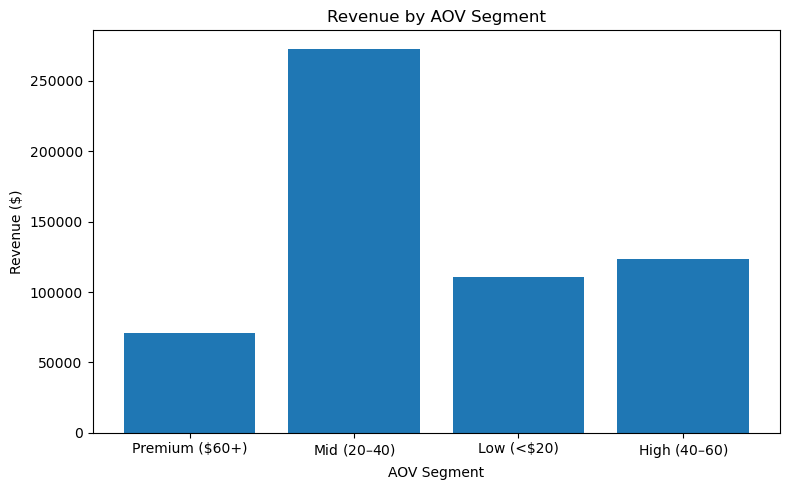

In [19]:
plt.figure(figsize=(8,5))
plt.bar(aov_df['aov_segment'], aov_df['total_revenue'])
plt.title('Revenue by AOV Segment')
plt.xlabel('AOV Segment')
plt.ylabel('Revenue ($)')
plt.tight_layout()
plt.show()

## 2.17 Discount Impact Analysis

- Evaluate how discounts affect revenue and order behavior.
- Measure:
  - share of orders with discounts
  - total discount dollars
  - average discount per discounted order
- Compare performance between discounted and non-discounted orders:
  - AOV
  - order volume
- This helps determine whether discounts are driving growth or eroding revenue.

In [20]:
# Overall discount metrics
con.execute("""
SELECT
    COUNT(*) AS total_orders,
    SUM(CASE WHEN discount_amount > 0 THEN 1 ELSE 0 END) AS discounted_orders,
    SUM(discount_amount) AS total_discount_amount,
    AVG(CASE WHEN discount_amount > 0 THEN discount_amount END) AS avg_discount_per_discounted_order
FROM orders_clean
""").fetchdf()

,total_orders,discounted_orders,total_discount_amount,avg_discount_per_discounted_order
0,22156,140.0,577.18,4.122714


## 2.18 Discount vs Non-Discount Performance

- Split orders into discounted vs non-discounted groups.
- Compare:
  - total orders
  - total revenue
  - AOV
- Identify whether discounted orders increase ticket size or simply reduce revenue per order.

In [21]:
disc_df = con.execute("""
SELECT
    CASE 
        WHEN discount_amount > 0 THEN 'Discounted'
        ELSE 'Non-Discounted'
    END AS discount_flag,
    COUNT(*) AS total_orders,
    SUM(order_total) AS total_revenue,
    AVG(order_total) AS avg_order_value
FROM orders_clean
GROUP BY discount_flag
""").fetchdf()

disc_df

,discount_flag,total_orders,total_revenue,avg_order_value
0,Non-Discounted,22016,573727.52,26.059571
1,Discounted,140,3564.14,25.458143


## 2.19 Discount Impact Visualization

- Visualize AOV difference between discounted and non-discounted orders.
- Identify whether discounts are increasing spend or lowering effective revenue.

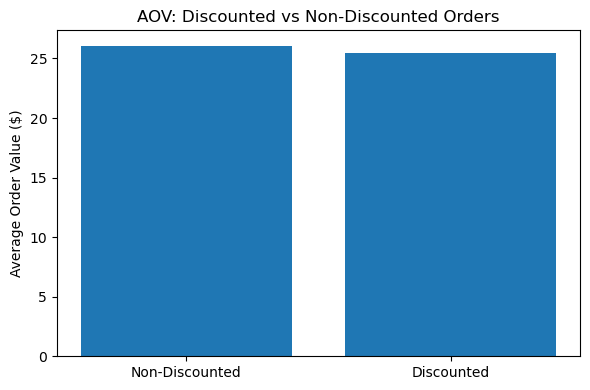

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(disc_df['discount_flag'], disc_df['avg_order_value'])
plt.title('AOV: Discounted vs Non-Discounted Orders')
plt.ylabel('Average Order Value ($)')
plt.tight_layout()
plt.show()

## 2.20 Server Performance Analysis

- Analyze performance at the server level to understand the human impact on revenue generation.
- Measure:
  - total orders handled
  - total revenue generated
  - average order value (AOV)
  - total guests served
- Identify top-performing and underperforming servers.
- This analysis can highlight differences in upselling behavior, table management, and customer interaction.
- Insights from this section can inform training, scheduling, and performance optimization.

In [23]:
server_df = con.execute("""
SELECT
    server_name,
    COUNT(*) AS total_orders,
    SUM(order_total) AS total_revenue,
    AVG(order_total) AS avg_order_value,
    SUM(guest_count) AS total_guests
FROM orders_clean
GROUP BY server_name
ORDER BY total_revenue DESC
""").fetchdf()

server_df

,server_name,total_orders,total_revenue,avg_order_value,total_guests
0,Zachary O'Brian,5868,155147.51,26.439589,6895.0
1,Jessica Mccullar,5983,125666.76,21.003971,6144.0
2,Chelsea Williams,3860,115503.30,29.923135,3939.0
3,Giovanni Cortes,2196,47306.88,21.542295,2248.0
4,victor pinacho,1304,39167.79,30.036649,3124.0
5,Diane Jean Mccullar,1007,31438.80,31.220258,1888.0
6,Shaylee Avery,754,26864.01,35.628660,767.0
7,Luis Cortes,758,22603.02,29.819288,1329.0
8,Julie Gates,423,13509.11,31.936430,1057.0
9,Clint Brown,2,64.48,32.240000,5.0


## 2.21 Server Revenue Distribution Visualization

- Visualize total revenue generated by each server.
- Identify concentration of revenue across staff.
- Determine whether revenue is evenly distributed or driven by a small subset of servers.

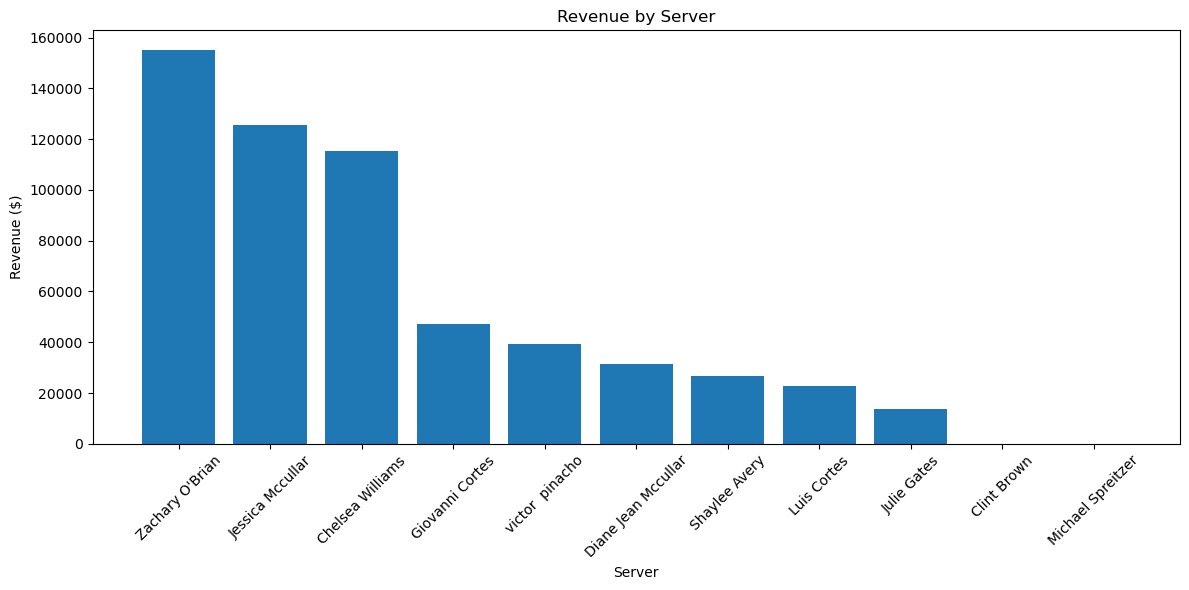

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(server_df['server_name'], server_df['total_revenue'])
plt.title('Revenue by Server')
plt.xlabel('Server')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2.22 Server Efficiency (AOV Comparison)

- Compare AOV across servers to evaluate differences in order value.
- Identify whether certain servers consistently generate higher-value transactions.
- This can indicate stronger upselling, better customer engagement, or table management practices.

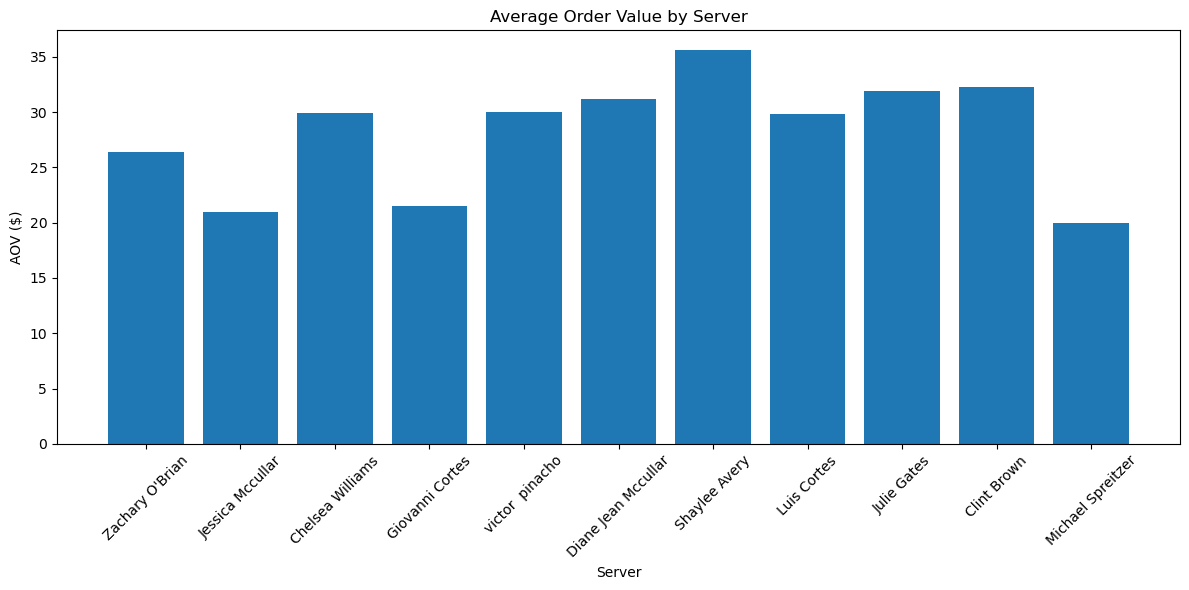

In [25]:
plt.figure(figsize=(12, 6))
plt.bar(server_df['server_name'], server_df['avg_order_value'])
plt.title('Average Order Value by Server')
plt.xlabel('Server')
plt.ylabel('AOV ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2.23 Revenue vs Order Share (Server Concentration)

- Compare each server’s share of total orders vs share of total revenue.
- Identify whether revenue is concentrated among a few servers or evenly distributed.
- Detect servers who generate higher revenue relative to their order volume (efficiency signal).
- This helps uncover performance differences beyond simple volume metrics.

In [26]:
# Compute shares
total_rev = server_df['total_revenue'].sum()
total_ord = server_df['total_orders'].sum()

server_df['revenue_share_pct'] = (server_df['total_revenue'] / total_rev) * 100
server_df['order_share_pct'] = (server_df['total_orders'] / total_ord) * 100

server_df.sort_values('revenue_share_pct', ascending=False)

,server_name,total_orders,total_revenue,avg_order_value,total_guests,revenue_share_pct,order_share_pct
0,Zachary O'Brian,5868,155147.51,26.439589,6895.0,26.875065,26.484925
1,Jessica Mccullar,5983,125666.76,21.003971,6144.0,21.768331,27.003972
2,Chelsea Williams,3860,115503.30,29.923135,3939.0,20.007789,17.421917
3,Giovanni Cortes,2196,47306.88,21.542295,2248.0,8.194624,9.911536
4,victor pinacho,1304,39167.79,30.036649,3124.0,6.784749,5.885539
5,Diane Jean Mccullar,1007,31438.80,31.220258,1888.0,5.445913,4.545044
6,Shaylee Avery,754,26864.01,35.628660,767.0,4.653455,3.403141
7,Luis Cortes,758,22603.02,29.819288,1329.0,3.915355,3.421195
8,Julie Gates,423,13509.11,31.936430,1057.0,2.340084,1.909189
9,Clint Brown,2,64.48,32.240000,5.0,0.011169,0.009027


## 2.24 Revenue vs Order Share Visualization

- Visualize differences between order share and revenue share.
- Identify servers who outperform (higher revenue share than order share).
- Highlight potential upselling or service efficiency differences.

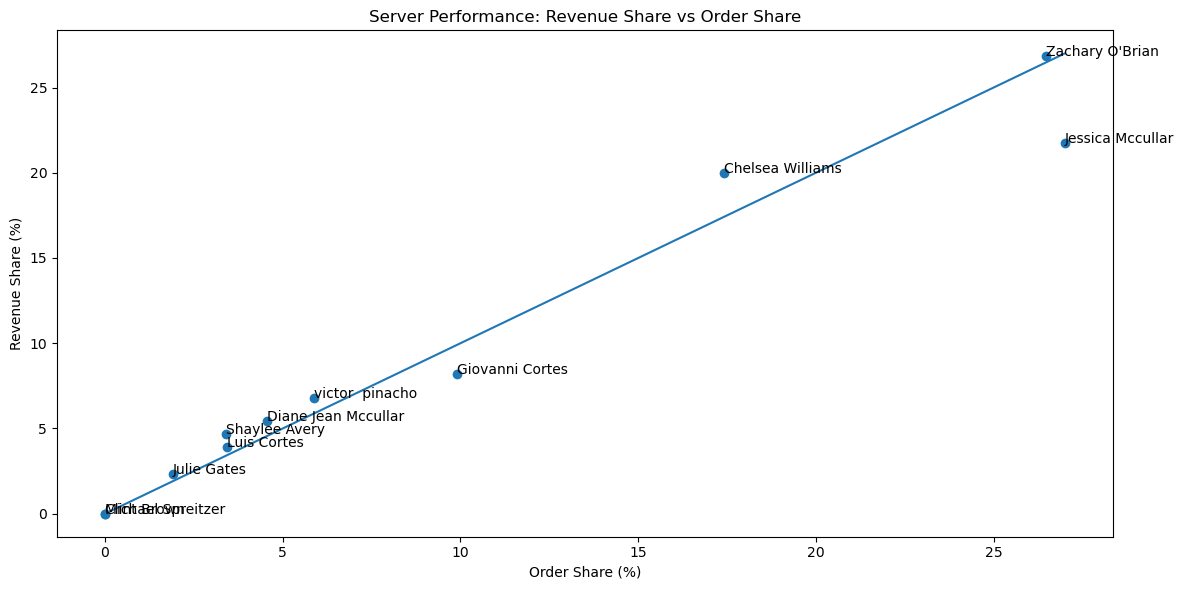

In [27]:
plt.figure(figsize=(12,6))

plt.scatter(
    server_df['order_share_pct'],
    server_df['revenue_share_pct']
)

for i, txt in enumerate(server_df['server_name']):
    plt.annotate(txt,
                 (server_df['order_share_pct'].iloc[i],
                  server_df['revenue_share_pct'].iloc[i]))

plt.plot([0, max(server_df['order_share_pct'])],
         [0, max(server_df['order_share_pct'])])  # reference line

plt.xlabel('Order Share (%)')
plt.ylabel('Revenue Share (%)')
plt.title('Server Performance: Revenue Share vs Order Share')
plt.tight_layout()
plt.show()

## 2.25 KPI Layer Summary

- The KPI layer successfully establishes a multi-level view of business performance:
  - overall business KPIs
  - quarterly trends
  - daily patterns
  - day-of-week and hour-of-day behavior
- Revenue is primarily driven by time-based demand patterns rather than discount strategy.
- Discount usage is minimal and does not significantly impact revenue performance.
- Server-level analysis reveals variation in revenue contribution and efficiency across staff.
- AOV segmentation highlights how different ticket sizes contribute to overall revenue.

- The dataset is now fully prepared for deeper behavioral and strategic analysis.

- The next stage will focus on:
  - identifying revenue drivers
  - uncovering operational constraints
  - building actionable business recommendations

## 2.26 SQL KPI Validation

- Replicate key KPI calculations using SQL.
- Ensures consistency between Python and SQL workflows.

In [29]:
con.execute("""
SELECT
    COUNT(*) AS total_orders,
    SUM(order_total) AS total_revenue,
    ROUND(AVG(order_total), 2) AS avg_order_value
FROM orders_clean
""").fetchdf()

,total_orders,total_revenue,avg_order_value
0,22156,577291.66,26.06
